In [1]:
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestRegressor 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
COLUNAS_REMOCAO = ["FID", "PAT", "MAT", "SEX", "PHENOTYPE"]

In [3]:
fenotipo = pd.read_csv('banco_fenotipos_conformal.csv')
caminho = ('Banco Genetico Imputado LD')
df_completo = None
for arquivo in os.listdir(caminho):
    if arquivo.endswith('.raw'):
        df_gen = pd.read_csv(f'{caminho}/{arquivo}',sep='\s+')
        df_gen = df_gen.drop(columns=COLUNAS_REMOCAO)
        if df_completo is None:
            df_completo = df_gen
        else:
            df_completo = pd.merge(left=df_completo,right=df_gen,on='IID',how='inner')

df_final = pd.merge(left=fenotipo,right=df_completo,left_on='samplefilename',right_on='IID',how='inner')
df_final = df_final.dropna(subset=['glicose_mg_dl'])

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
C:\Users\mateu\AppData\Local\Temp\ipykernel_10972\3003404813.py:6: SyntaxWarning: invalid escape sequence '\s'
  df_gen = pd.read_csv(f'{caminho}/{arquivo}',sep='\s+')


In [4]:
np.random.seed(67)
colunas_para_ignorar = ['glicose_mg_dl', 'IID', 'samplefilename','diabetes2','HOMA_IR','medDM_bioq']

# O errors='ignore' evita que o código quebre se alguma dessas 
# colunas já não existir mais no banco
X = df_final.drop(columns=colunas_para_ignorar, errors='ignore')
y = df_final['glicose_mg_dl']

In [5]:
colunas_categoricas = ['fumo', 'raca_cor', 'conjugal3', 'trabalho2', 'bebem2']

# 3. A MÁGICA DA TRADUÇÃO (One-Hot Encoding)
# drop_first=True evita redundância matemática. dtype=int garante que saia 0 e 1 em vez de True/False.
X_arrumado = pd.get_dummies(X, columns=colunas_categoricas, drop_first=True, dtype=int)

In [6]:
# ==========================================
# 3. DIVIDINDO EM TREINO E TESTE
# ==========================================
# Separamos 80% dos indivíduos para o modelo
# e 20% para testarmos se ele aprendeu bem com dados inéditos (teste)
X_treino, X_teste, y_treino, y_teste = train_test_split(X_arrumado, y, test_size=0.2, random_state=67)

In [7]:
# ==========================================
# 4. CRIANDO E TREINANDO O MODELO
# ==========================================
# n_estimators=1000 significa que ele vai criar 1000 árvores de decisão
modelo_rf = RandomForestRegressor(n_estimators=1000, random_state=67, n_jobs=5, max_features=0.07, oob_score=True)

# O comando .fit() é onde a mágica acontece. O modelo aprende a relação
# entre a genética/clínica (X) e o fenótipo (y).
modelo_rf.fit(X_treino, y_treino)

RandomForestRegressor(max_features=0.07, n_estimators=1000, n_jobs=5,
                      oob_score=True, random_state=67)

In [8]:
# ==========================================
# 5. TESTANDO O MODELO (PREVISÕES)
# ==========================================
# Agora pedimos para ele prever o desfecho dos 20% separados para teste
previsoes = modelo_rf.predict(X_teste)

In [9]:
# ==========================================
# 6. AVALIANDO O DESEMPENHO
# ==========================================
# Comparamos as previsões que o modelo fez com os valores reais (y_teste)
mse = mean_squared_error(y_teste, previsoes)
r2 = r2_score(y_teste, previsoes)

print(f"Erro Quadrático Médio (MSE): {mse:.2f}")
print(f"R² (Coeficiente de Determinação): {r2:.2f}")
print(f"OOB Score (R² estimado): {modelo_rf.oob_score_:.4f}")

Erro Quadrático Médio (MSE): 1339.05
R² (Coeficiente de Determinação): 0.06
OOB Score (R² estimado): 0.0177


In [10]:
# Pega as importâncias matemáticas do modelo
importancias = modelo_rf.feature_importances_

# Pega o nome das 244 mil colunas do seu X
nomes_variaveis = X_treino.columns

# Cria uma tabela bonita ligando o nome ao valor de importância
tabela_importancia = pd.DataFrame({
    'Variavel': nomes_variaveis,
    'Importancia': importancias
})
top_20 = tabela_importancia.sort_values(by='Importancia', ascending=False).head(100)
print(top_20)

            Variavel  Importancia
3              idade     0.009106
5                imc     0.007711
127998  rs17389100_G     0.006920
112487   rs6040200_C     0.006910
204361   rs7760400_G     0.006636
...              ...          ...
101140  rs58615638_G     0.001527
91262   rs73062632_G     0.001524
174376   rs1522565_T     0.001509
193702   rs1927584_A     0.001494
216447   rs6466355_C     0.001485

[100 rows x 2 columns]


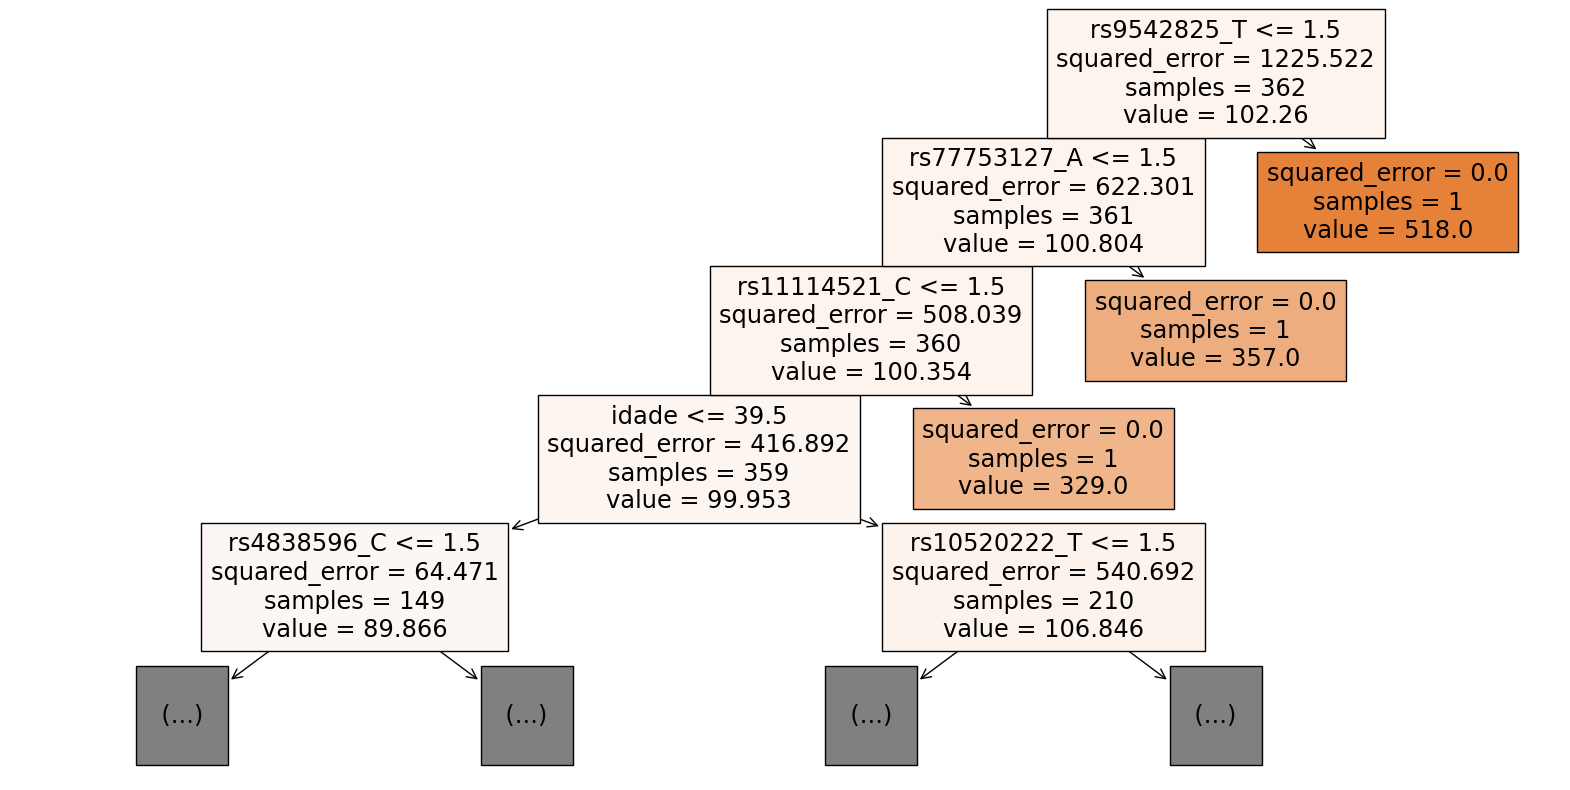

In [11]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Plotar a primeira árvore do Random Forest
plt.figure(figsize=(20,10))
plot_tree(modelo_rf.estimators_[1], feature_names=X_treino.columns, filled=True, max_depth=4)
plt.show()